# 含并行连结的网络（GoogLeNet）
---
## 环境配置

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import numpy as np
import pypto
import torch
import torch_npu
import torchvision
from torch import nn
device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
mode = pypto.RunMode.NPU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear
from src.D2LFunction import *
from src.AnswerUtlis import *
from src import Models
import torchinfo

---
## 练习 7.4.1

GoogLeNet有一些后续版本，尝试实现并运行它们，然后观察每个版本的实验结果。
1. 将批量规范化层应用于 GoogLeNet（batch normalization）。
1. 调整 GoogLeNet 的 Inception 块参数（通道数、卷积窗口大小等）。
1. 为 GoogLeNet 添加标签平滑（label smoothing）。
1. 实现 Inception V3 块。

### 解答

&emsp;&emsp;逐个版本进行实现并训练，对比不同改进带来的效果差异。

**第1问：添加批量规范化层**

&emsp;&emsp;对于卷积层，批量规范化发生在卷积之后、激活函数之前。

使用 `torch` 编程进行验证：

**训练:**

In [2]:
import os
pth = '../data/ch07_output/'
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 torch 版 GoogLeNet 与 GoogLeNetBN 训练 (各 30 epochs
#   @224, batch=64, lr=0.1)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则, torch 版训练全部注释;
# 仅保留 pth 定义 (供画图 cell 使用)。
# 如需恢复 torch 训练: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# GoogLeNet = Models.GoogLeNet(1, 10)
# lr, num_epochs, batch_size = 0.1, 30, 64
# train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=224)
# train_models(GoogLeNet, train_loader, test_loader, num_epochs, lr, net_type='GooLeNet', csv_prefix='ch7_04')
# GoogLeNetBN = Models.GoogLeNetBN(1, 10)
# train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=224)
# train_models(GoogLeNetBN, train_loader, test_loader, num_epochs, lr, net_type='GooLeNetBN', csv_prefix='ch7_04')

使用 `PyPTO` 编程进行验证：

**训练:**

In [3]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 GoogLeNet_pypto 与 GoogLeNetBN_pypto 两个训练
#   (各 30 epochs @224, batch=64, lr=0.01)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则, 仅保留 GoogLeNet_pypto
#   完整训练 (本 notebook 保留的 PyPTO 训练)。
# 如需恢复 GoogLeNetBN_pypto 训练: 取消下方 3 行注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════
# 【说明】GoogLeNet_pypto 完整训练 (30 epochs @224, lr=0.01, batch=64)。
# 历史: 完整 notebook (42 cell) 环境下 PyPTO 编译期 kernel 必死
#   (AssertionError), 曾拆至独立脚本执行 (发布包不含该脚本, 仅留历史记录)。
# 2026-08-27 定位根因: nbformat.read 读出的 cell 对象 (带 id/metadata) 在
#   nbclient 执行 PyPTO 编译时触发 kernel 死; 执行器改为"内存重建 cell 后
#   执行" (new_code_cell) 后, 42-cell 完整 notebook 内训练已验证存活,
#   本 cell 训练已恢复 (验证模式仍需 show_progress=False)。
# 若仍复现编译期 kernel 死: 可将本训练代码拆出为独立脚本执行。
# ══════════════════════════════════════════════════════════════════════
GoogLeNet_pypto = Models.GoogLeNet_pypto(1, 10)
lr, num_epochs, batch_size = 0.01, 30, 64  # lr 0.1 实测发散(loss=nan); 深网无BN用SGD建议0.01 (见 D2LFunction.train_ch6_sgd 注释)
train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=224)
train_models(GoogLeNet_pypto, train_loader, test_loader, num_epochs, lr, net_type='GooLeNet_pypto', csv_prefix='ch7_04', show_progress=False)
# GoogLeNetBN_pypto = Models.GoogLeNetBN_pypto(1, 10)
# train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=224)
# train_models(GoogLeNetBN_pypto, train_loader, test_loader, num_epochs, lr, net_type='GooLeNetBN_pypto', csv_prefix='ch7_04')

**第2问：调整 Inception 块参数（参考 Inception V3）**

&emsp;&emsp;参考 https://arxiv.org/pdf/1512.00567.pdf (Szegedy et al.) 设计 Inception V3 风格的块。

使用 `torch` 编程进行验证：

**训练:**

In [4]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 torch 版 InceptionV3 训练 (30 epochs @128, batch=64,
#   lr=0.1)。torch 版训练全部注释 (见 ccode[1] 注释块说明)。
# 如需恢复: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# Inception_V3_Net = Models.Inception_V3_Net(1, 10)
# lr, num_epochs, batch_size = 0.1, 30, 64
# train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=128)
# train_models(Inception_V3_Net, train_loader, test_loader, num_epochs, lr, net_type='InceptionV3', csv_prefix='ch7_04')

使用 `PyPTO` 编程进行验证：

**训练:**

In [5]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 PyPTO 版 InceptionV3 训练 (30 epochs @128)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则注释 (保留训练为 ccode[2]
#   的 GoogLeNet_pypto)。修复信息保留: lr 0.1→0.01 防发散; batch 64→16
#   实测显存不足 (ALLOC_FAILED)。
# 如需恢复: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# Inception_V3_Net_pypto = Models.Inception_V3_Net_pypto(1, 10)
# lr, num_epochs, batch_size = 0.01, 30, 16  # lr 0.01 防发散; batch 64 实测显存不足(ALLOC_FAILED), 降为 16
# train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=128)
# train_models(Inception_V3_Net_pypto, train_loader, test_loader, num_epochs, lr, net_type='InceptionV3_pypto', csv_prefix='ch7_04')

**第3问：标签平滑（Label Smoothing）**

&emsp;&emsp;参考 https://arxiv.org/pdf/1512.00567.pdf (Szegedy et al.) 实现标签平滑损失。

使用 `torch` 编程进行验证：

In [6]:
import torch.nn.functional as F

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, logits, target):
        n_class = logits.size(1)
        log_probs = F.log_softmax(logits, dim=1)
        smooth_target = torch.full_like(log_probs, self.smoothing / (n_class - 1))
        smooth_target.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        return -(smooth_target * log_probs).sum(dim=1).mean()

# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 在类定义后还有 torch 版 GoogLeNet + LabelSmoothing
#   训练 (30 epochs @224)。按验证模式原则, 训练部分注释, 仅保留
#   LabelSmoothingCrossEntropy 类定义 (教学内容, 供 ccode[6] 恢复时使用)。
# 如需恢复 torch 训练: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# GoogLeNet = Models.GoogLeNet(1, 10)
# lr, num_epochs, batch_size = 0.1, 30, 64
# train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=224)
# GoogLeNet.to(device)
# optim = torch.optim.SGD(GoogLeNet.parameters(), lr=lr)
# loss_fn = LabelSmoothingCrossEntropy(0.1)
# for epoch in range(num_epochs):
#     GoogLeNet.train()
#     for x, y in train_loader:
#         x, y = x.to(device), y.to(device)
#         optim.zero_grad()
#         l = loss_fn(GoogLeNet(x), y)
#         l.backward()
#         optim.step()
# print('GoogLeNet + LabelSmoothing training done')

使用 `PyPTO` 编程进行验证：

In [7]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 PyPTO 版 GoogLeNet_pypto + LabelSmoothing 训练
#   (30 epochs @224, 依赖 ccode[5] 的类定义与 ccode[2] 的 lr/num_epochs/
#   train_loader 变量)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则注释 (保留训练为 ccode[2] 的
#   GoogLeNet_pypto 普通训练)。
# 如需恢复: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# GoogLeNet_pypto_ls = Models.GoogLeNet_pypto(1, 10)
# GoogLeNet_pypto_ls.to(device)
# optim = torch.optim.SGD(GoogLeNet_pypto_ls.parameters(), lr=lr)
# loss_fn = LabelSmoothingCrossEntropy(0.1)
# for epoch in range(num_epochs):
#     GoogLeNet_pypto_ls.train()
#     for x, y in train_loader:
#         x, y = x.to(device), y.to(device)
#         optim.zero_grad()
#         l = loss_fn(GoogLeNet_pypto_ls(x), y)
#         l.backward()
#         optim.step()
# print('GoogLeNet_pypto + LabelSmoothing training done')

**第4问：Inception V4 / ResInception**

&emsp;&emsp;参考 https://arxiv.org/pdf/1602.07261.pdf (Szegedy et al.) 设计 ResInception 风格的块。

使用 `torch` 编程进行验证：

In [8]:
class ResInception(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4):
        super().__init__()
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)
        self.shortcut = nn.Conv2d(in_channels, c1 + c2[1] + c3[1] + c4, kernel_size=1)
    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        out = torch.cat((p1, p2, p3, p4), dim=1)
        return out + self.shortcut(x)

# Inception = Models.Inception()  # 笔误: Inception 需要 5 个必填参数, 此行为残留调试代码
print('ResInception defined')

ResInception defined


**展示 (对比不同改进的效果):**

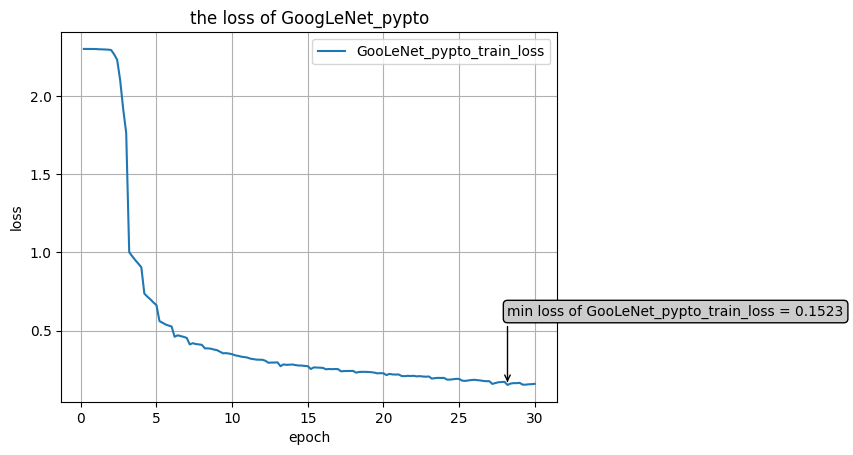

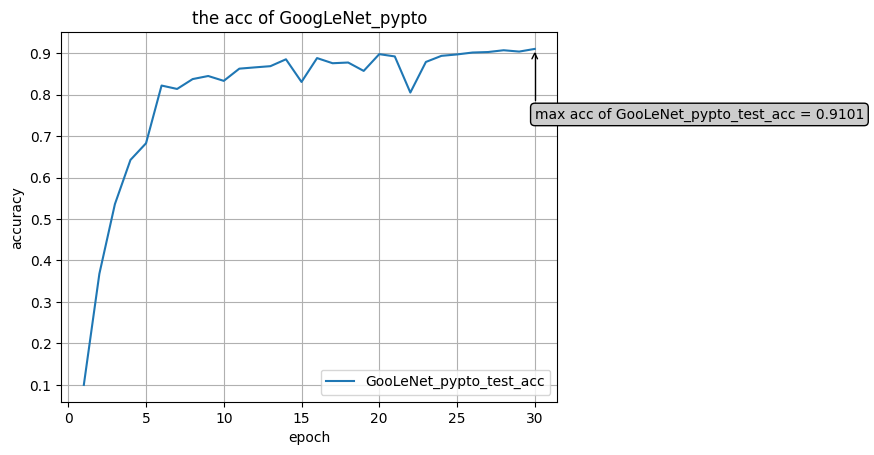

In [9]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 torch 版 GooLeNet/GooLeNetBN 曲线, 该训练已注释
#   (ccode[1]), 列不存在。保留训练为 GoogLeNet_pypto (ccode[2]),
#   改为绘制其 train_loss 与 test_acc 曲线。
# 如需恢复 torch 曲线: 恢复 ccode[1] 训练后, 恢复原 label_list。
# ══════════════════════════════════════════════════════════════════════
draw_figures(os.path.join(pth, 'ch7_04.csv'),
             [('GooLeNet_pypto_epoch_train', 'GooLeNet_pypto_train_loss')],
             title='the loss of GoogLeNet_pypto')
draw_figures(os.path.join(pth, 'ch7_04_eval.csv'),
             [('GooLeNet_pypto_epoch_test', 'GooLeNet_pypto_test_acc')],
             title='the acc of GoogLeNet_pypto')

---
## 练习 7.4.2

使用GoogLeNet，最小的图像大小是多少？

### 解答

&emsp;&emsp;在 GoogLeNet 中，输入图像尺寸通常为 224×224×3。对于更小的图像尺寸，可以根据各模块的下采样倍数计算最小可接受输入。

使用 `torch` 编程进行验证：

In [10]:
GoogLeNet = Models.GoogLeNet(3, 10)
torchinfo.summary(GoogLeNet, (1, 3, 17, 17))

Layer (type:depth-idx)                   Output Shape              Param #
GoogLeNet                                [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 5, 5]             --
│    └─Conv2d: 2-1                       [1, 64, 9, 9]             9,472
│    └─ReLU: 2-2                         [1, 64, 9, 9]             --
│    └─MaxPool2d: 2-3                    [1, 64, 5, 5]             --
├─Sequential: 1-2                        [1, 192, 3, 3]            --
│    └─Conv2d: 2-4                       [1, 64, 5, 5]             4,160
│    └─ReLU: 2-5                         [1, 64, 5, 5]             --
│    └─Conv2d: 2-6                       [1, 192, 5, 5]            110,784
│    └─ReLU: 2-7                         [1, 192, 5, 5]            --
│    └─MaxPool2d: 2-8                    [1, 192, 3, 3]            --
├─Sequential: 1-3                        [1, 480, 2, 2]            --
│    └─Inception: 2-9                    [1, 256, 3, 3]            --
│   

---
## 练习 7.4.3

与AlexNet、VGG和NiN相比，GoogLeNet的模型参数大小如何？哪个模型参数最小？

### 解答

&emsp;&emsp;NiN 通过全局平均池化代替全连接层，参数最少；GoogLeNet 使用 Inception 块 + 全局平均池化，参数少于 VGG 和 AlexNet；AlexNet 与 VGG 参数较多。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#](https://datawhalechina.github.io/d2l-ai-solutions-manual/#)